# Tech Challenge Fase 1 — Case NPS Preditivo
## Notebook 1: Limpeza, Tratamento e Análise Exploratória (EDA)

Este notebook cobre as etapas **Data Understanding** e **Data Preparation** do CRISP-DM:

1. Carga e validação da base
2. Verificações de integridade (nulos, duplicados, outliers, ranges)
3. Análise univariada e bivariada
4. Estudo de correlação
5. Identificação de drivers de NPS

> **Observação sobre a base:** após análise inicial, a base se mostrou bastante consistente — sem nulos, sem duplicados e com tipos coerentes.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

# Configurações visuais
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Carregar base
CAMINHO_DADOS = '../data/desafio_nps_fase_1.csv'
df = pd.read_csv(CAMINHO_DADOS)
print(f'Base carregada: {df.shape[0]} linhas, {df.shape[1]} colunas')

Base carregada: 2500 linhas, 19 colunas


## 2. Verificações de integridade

Antes de afirmar que a base "está limpa", precisamos checar:

| Verificação | O que estamos procurando |
|---|---|
| Nulos | Campos vazios que precisam de tratamento |
| Duplicados | Linhas inteiras repetidas |
| Chaves duplicadas | `customer_id` ou `order_id` repetidos (afeta a interpretação) |
| Tipos | Colunas numéricas como string, datas como object, etc. |
| Ranges | Idades negativas, NPS > 10, valores impossíveis |
| Outliers | Valores extremos que distorcem a análise |

In [2]:
# 2.1 Visão geral
print('=' * 60)
print('VISÃO GERAL')
print('=' * 60)
df.info()

print('\n' + '=' * 60)
print('PRIMEIRAS LINHAS')
print('=' * 60)
display(df.head())

print('\n' + '=' * 60)
print('ESTATÍSTICAS DESCRITIVAS')
print('=' * 60)
display(df.describe().round(2))

VISÃO GERAL
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int6

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9



ESTATÍSTICAS DESCRITIVAS


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [3]:
# 2.2 Integridade dos dados
nulos = df.isnull().sum().sum()
duplicadas = df.duplicated().sum()
dup_order = df['order_id'].duplicated().sum()
dup_customer = df['customer_id'].duplicated().sum()

print(f'Linhas: {df.shape[0]:,}')
print(f'Colunas: {df.shape[1]}')
print(f'Valores nulos (total): {nulos}')
print(f'Linhas duplicadas: {duplicadas}')
print(f'order_id duplicados: {dup_order}')
print(f'customer_id duplicados: {dup_customer} '
      f'→ {"cada cliente aparece 1 vez" if dup_customer == 0 else "há clientes com múltiplos pedidos"}')

Linhas: 2,500
Colunas: 19
Valores nulos (total): 0
Linhas duplicadas: 0
order_id duplicados: 0
customer_id duplicados: 0 → cada cliente aparece 1 vez


In [4]:
# 2.3 Validação de ranges esperados
# Conforme dicionário do PDF, valores que devem estar dentro de limites lógicos
validacoes = [
    ('customer_age', 0, 120, 'idade plausível'),
    ('customer_tenure_months', 0, None, 'tenure não pode ser negativo'),
    ('order_value', 0, None, 'valor não pode ser negativo'),
    ('delivery_delay_days', 0, None, 'atraso não pode ser negativo'),
    ('nps_score', 0, 10, 'NPS deve estar entre 0 e 10'),
    ('repeat_purchase_30d', 0, 1, 'flag binária'),
    ('csat_internal_score', 0, 10, 'CSAT geralmente é 0-10'),
]

print('VALIDAÇÃO DE RANGES')
print('-' * 70)
for coluna, vmin, vmax, descricao in validacoes:
    real_min = df[coluna].min()
    real_max = df[coluna].max()
    ok_min = real_min >= vmin
    ok_max = (vmax is None) or (real_max <= vmax)
    status = '✓' if (ok_min and ok_max) else '✗'
    print(f'{status} {coluna:30s} min={real_min:>7.2f} max={real_max:>7.2f} ({descricao})')

VALIDAÇÃO DE RANGES
----------------------------------------------------------------------
✓ customer_age                   min=  18.00 max=  69.00 (idade plausível)
✓ customer_tenure_months         min=   1.00 max= 119.00 (tenure não pode ser negativo)
✓ order_value                    min=   7.76 max=1983.81 (valor não pode ser negativo)
✓ delivery_delay_days            min=   0.00 max=   8.00 (atraso não pode ser negativo)
✓ nps_score                      min=   0.00 max=  10.00 (NPS deve estar entre 0 e 10)
✓ repeat_purchase_30d            min=   0.00 max=   1.00 (flag binária)
✓ csat_internal_score            min=   0.00 max=  10.00 (CSAT geralmente é 0-10)


### `nps_score` é contínuo, não inteiro

Apesar do dicionário do PDF afirmar que o NPS "varia de 0 a 10", os valores são **floats com casas decimais** (ex.: 7.3, 8.6). Isso muda a interpretação:

- **Não é um NPS coletado por pesquisa tradicional** (que costuma ser inteiro de 0 a 10)
- Pode ser uma nota **ponderada/estimada internamente** — talvez um *proxy* já calculado pela empresa
- Para a classificação Promotor/Neutro/Detrator, precisamos **definir como tratar valores fracionários** (vamos arredondar pra baixo: floor)

Esse achado já é, por si só, uma **observação relevante para o storytelling executivo**.

In [5]:
# Confirma que NPS tem valores não inteiros
nao_inteiros = (df['nps_score'] != df['nps_score'].astype(int)).sum()
print(f'NPS com casas decimais: {nao_inteiros} ({nao_inteiros/len(df)*100:.1f}%)')
print(f'Valores únicos de NPS: {df["nps_score"].nunique()}')

NPS com casas decimais: 2075 (83.0%)
Valores únicos de NPS: 101


## 3. Análise univariada — distribuição do NPS

In [6]:
# 3.1 Classificação NPS (regra de negócio padrão)
# Usamos floor() para tratar os decimais, de forma conservadora:
# 8.9 vira 8 → Neutro (não "sobe" para Promotor)
# 6.9 vira 6 → Detrator (não "sobe" para Neutro)
def classificar_nps(score):
    score_int = int(np.floor(score))
    if score_int >= 9:
        return 'Promotor'
    elif score_int >= 7:
        return 'Neutro'
    return 'Detrator'

df['classificacao_nps'] = df['nps_score'].apply(classificar_nps)

# Distribuição
dist = df['classificacao_nps'].value_counts(normalize=True).reindex(
    ['Detrator', 'Neutro', 'Promotor']
) * 100

print('Distribuição da base:')
for cat, pct in dist.items():
    print(f'  {cat:10s}: {pct:5.1f}%')

# Cálculo do NPS Score oficial (% Promotores - % Detratores)
nps_oficial = dist['Promotor'] - dist['Detrator']
print(f'\nNPS oficial: {nps_oficial:.1f}')
print(f'Interpretação: {"Excelente (>50)" if nps_oficial > 50 else "Bom (>0)" if nps_oficial > 0 else "Crítico (<=0)"}')

Distribuição da base:
  Detrator  :  84.4%
  Neutro    :  11.2%
  Promotor  :   4.4%

NPS oficial: -80.0
Interpretação: Crítico (<=0)


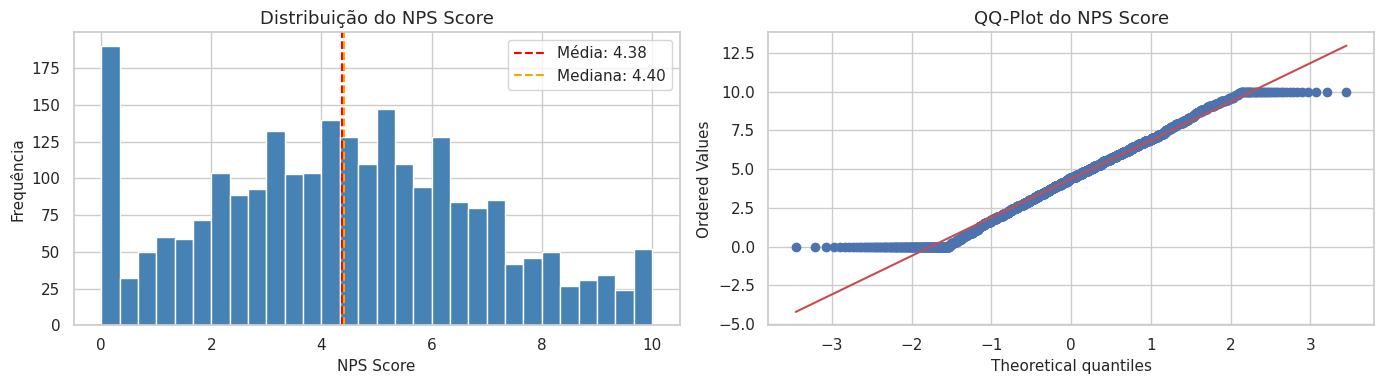

Conclusão visual:
  - Distribuição assimétrica à direita (cauda longa em valores altos)
  - Concentração próxima de 0: muitos detratores extremos
  - QQ-plot mostra desvio claro da normalidade


In [7]:
# 3.2 Histograma + QQ-Plot do NPS
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['nps_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do NPS Score')
axes[0].set_xlabel('NPS Score')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['nps_score'].mean(), color='red', linestyle='--', label=f'Média: {df["nps_score"].mean():.2f}')
axes[0].axvline(df['nps_score'].median(), color='orange', linestyle='--', label=f'Mediana: {df["nps_score"].median():.2f}')
axes[0].legend()

probplot(df['nps_score'], dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot do NPS Score')

plt.tight_layout()
plt.show()

print('Conclusão visual:')
print('  - Distribuição assimétrica à direita (cauda longa em valores altos)')
print('  - Concentração próxima de 0: muitos detratores extremos')
print('  - QQ-plot mostra desvio claro da normalidade')

### Sobre os NPS = 0: são outliers que devemos remover?

**Não.** Eles são clientes legítimos extremamente insatisfeitos — informação essencial para o problema de negócio. Remover seria:

1. **Mascarar a realidade** da empresa (que tem ~6% de detratores extremos)
2. **Inflar artificialmente o NPS**
3. **Perder o sinal mais forte** — quem dá nota 0 quase sempre teve um problema sério (atraso, reclamação, falha grave)

O critério para remover seria se eles fossem **erros de sistema** (ex.: clientes que não responderam e foram preenchidos com 0). Vamos verificar se eles têm padrão diferente do resto.

In [8]:
# Comparar NPS=0 vs resto da base
df_zero = df[df['nps_score'] == 0]
df_resto = df[df['nps_score'] > 0]

comparacao = pd.DataFrame({
    'NPS=0 (n={})'.format(len(df_zero)): df_zero[['delivery_delay_days', 'complaints_count',
                                                      'customer_service_contacts', 'csat_internal_score',
                                                      'repeat_purchase_30d']].mean(),
    'Resto (n={})'.format(len(df_resto)): df_resto[['delivery_delay_days', 'complaints_count',
                                                        'customer_service_contacts', 'csat_internal_score',
                                                        'repeat_purchase_30d']].mean()
}).round(2)

display(comparacao)
print('\nConclusão: clientes com NPS=0 têm mais atraso, mais reclamações e mais contatos com SAC.')
print('São detratores genuínos, não erros de sistema. MANTER NA BASE.')

,NPS=0 (n=158),Resto (n=2342)
delivery_delay_days,4.11,2.06
complaints_count,5.76,4.04
customer_service_contacts,2.65,1.44
csat_internal_score,0.70,3.09
repeat_purchase_30d,0.00,0.09



Conclusão: clientes com NPS=0 têm mais atraso, mais reclamações e mais contatos com SAC.
São detratores genuínos, não erros de sistema. MANTER NA BASE.


## 4. Análise bivariada — drivers do NPS

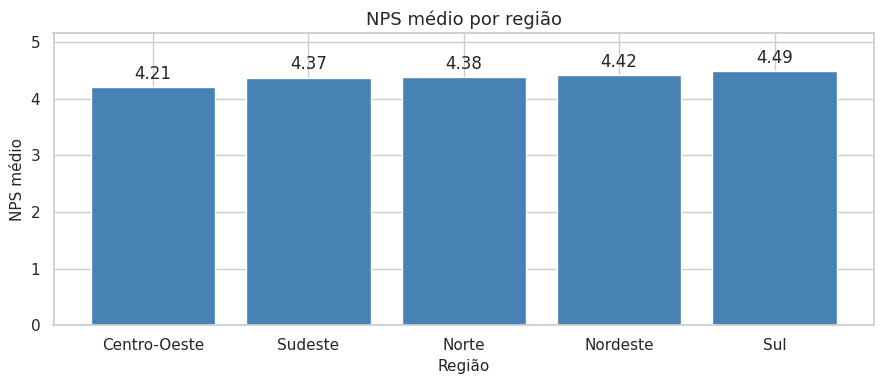

→ NPS é parecido entre regiões: o problema é SISTÊMICO, não regional.


In [9]:
# 4.1 NPS médio por região
nps_regiao = df.groupby('customer_region')['nps_score'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(nps_regiao.index, nps_regiao.values, color='steelblue')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_title('NPS médio por região')
ax.set_xlabel('Região')
ax.set_ylabel('NPS médio')
ax.set_ylim(0, max(nps_regiao.values) * 1.15)
plt.tight_layout()
plt.show()

print('→ NPS é parecido entre regiões: o problema é SISTÊMICO, não regional.')

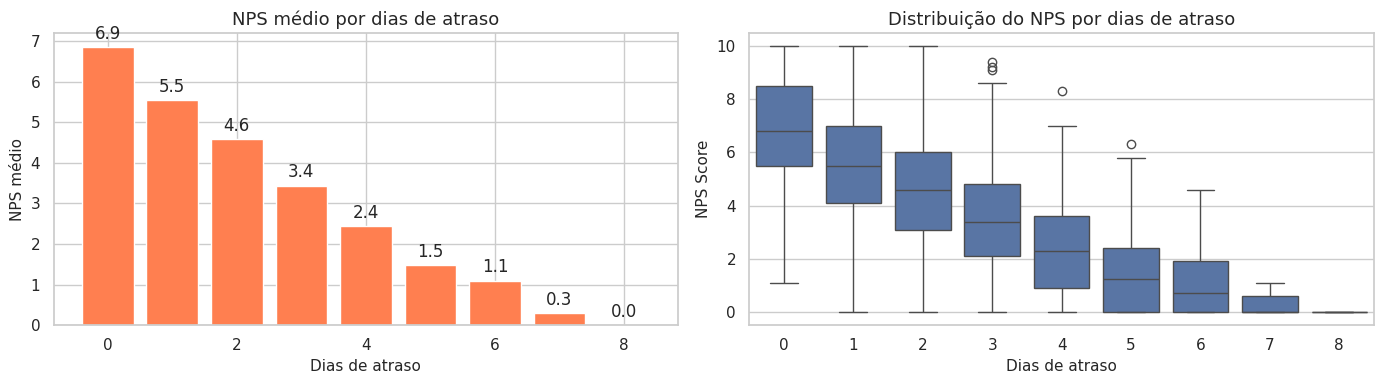

,mean,count
delivery_delay_days,,
0,6.86,277
1,5.55,615
2,4.58,646
3,3.44,525
4,2.44,270
5,1.48,116
6,1.10,34
7,0.29,14
8,0.00,3



→ PONTO DE RUPTURA: a partir do 1º dia de atraso, o NPS já cai significativamente.


In [10]:
# 4.2 NPS por dias de atraso na entrega
nps_atraso = df.groupby('delivery_delay_days')['nps_score'].agg(['mean', 'count']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars = axes[0].bar(nps_atraso.index, nps_atraso['mean'], color='coral')
axes[0].bar_label(bars, fmt='%.1f', padding=3)
axes[0].set_title('NPS médio por dias de atraso')
axes[0].set_xlabel('Dias de atraso')
axes[0].set_ylabel('NPS médio')

sns.boxplot(data=df, x='delivery_delay_days', y='nps_score', ax=axes[1])
axes[1].set_title('Distribuição do NPS por dias de atraso')
axes[1].set_xlabel('Dias de atraso')
axes[1].set_ylabel('NPS Score')

plt.tight_layout()
plt.show()

display(nps_atraso)
print('\n→ PONTO DE RUPTURA: a partir do 1º dia de atraso, o NPS já cai significativamente.')

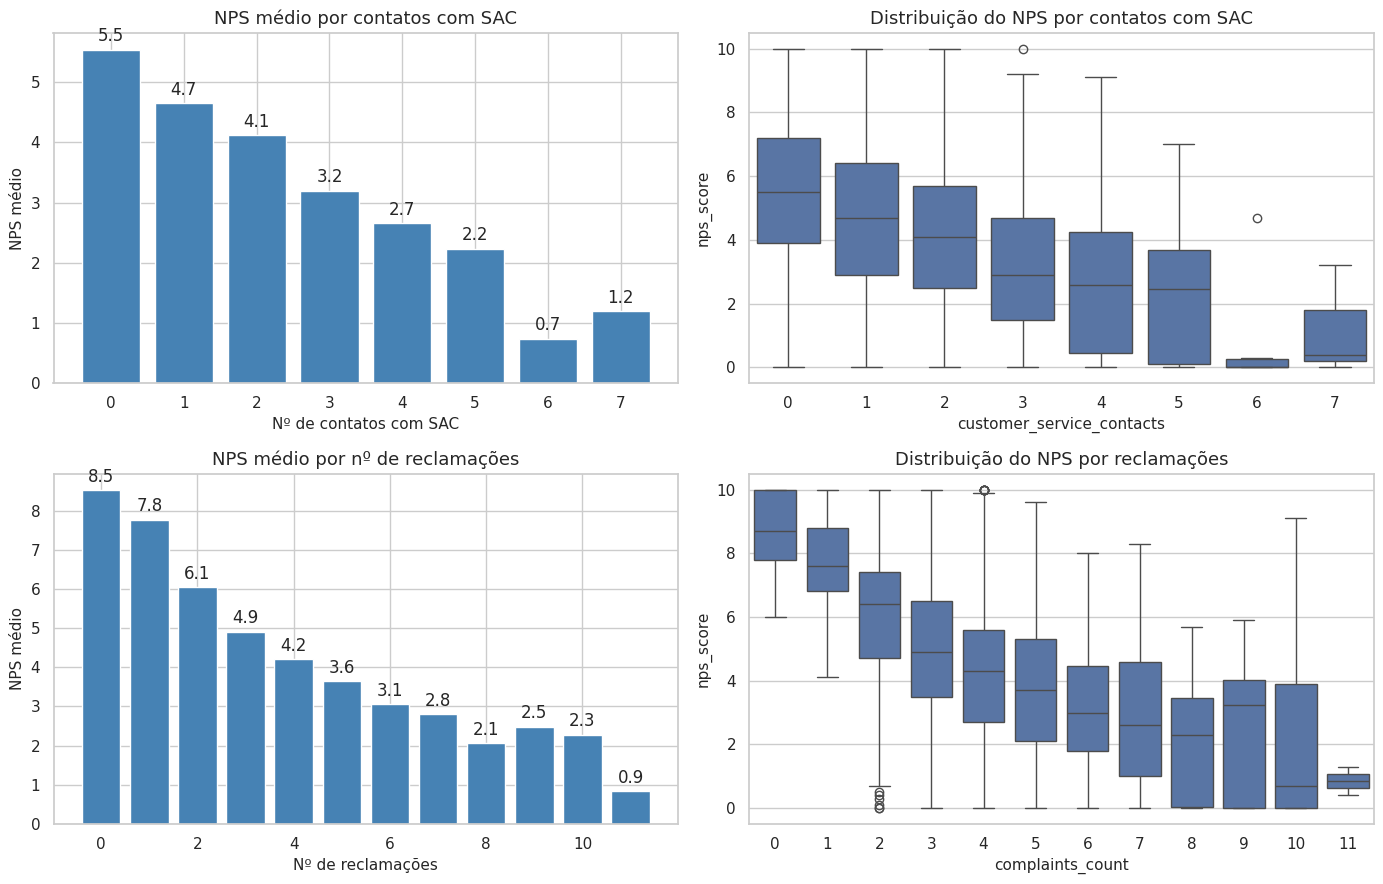

In [11]:
# 4.3 NPS por contatos com SAC e por reclamações
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# SAC - barras
nps_sac = df.groupby('customer_service_contacts')['nps_score'].mean()
bars = axes[0, 0].bar(nps_sac.index, nps_sac.values, color='steelblue')
axes[0, 0].bar_label(bars, fmt='%.1f', padding=3)
axes[0, 0].set_title('NPS médio por contatos com SAC')
axes[0, 0].set_xlabel('Nº de contatos com SAC')
axes[0, 0].set_ylabel('NPS médio')

# SAC - boxplot
sns.boxplot(data=df, x='customer_service_contacts', y='nps_score', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição do NPS por contatos com SAC')

# Reclamações - barras
nps_recla = df.groupby('complaints_count')['nps_score'].mean()
bars = axes[1, 0].bar(nps_recla.index, nps_recla.values, color='steelblue')
axes[1, 0].bar_label(bars, fmt='%.1f', padding=3)
axes[1, 0].set_title('NPS médio por nº de reclamações')
axes[1, 0].set_xlabel('Nº de reclamações')
axes[1, 0].set_ylabel('NPS médio')

# Reclamações - boxplot
sns.boxplot(data=df, x='complaints_count', y='nps_score', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição do NPS por reclamações')

plt.tight_layout()
plt.show()

## 5. Correlação geral — quem move o NPS?

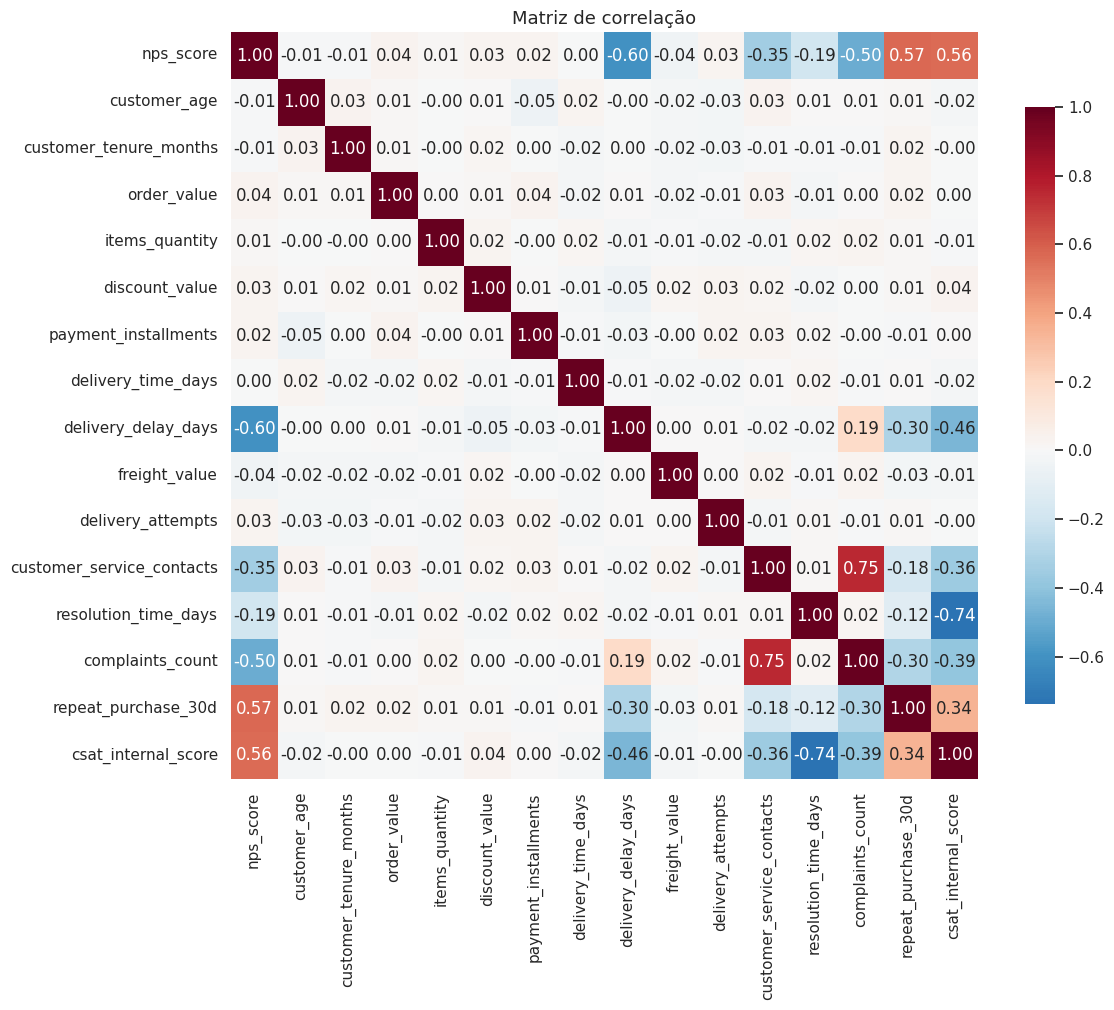

In [12]:
# 5.1 Correlação de Pearson
cols_numericas = ['nps_score', 'customer_age', 'customer_tenure_months', 'order_value',
                  'items_quantity', 'discount_value', 'payment_installments',
                  'delivery_time_days', 'delivery_delay_days', 'freight_value',
                  'delivery_attempts', 'customer_service_contacts', 'resolution_time_days',
                  'complaints_count', 'repeat_purchase_30d', 'csat_internal_score']

corr = df[cols_numericas].corr()

# Heatmap completo
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de correlação')
plt.tight_layout()
plt.show()

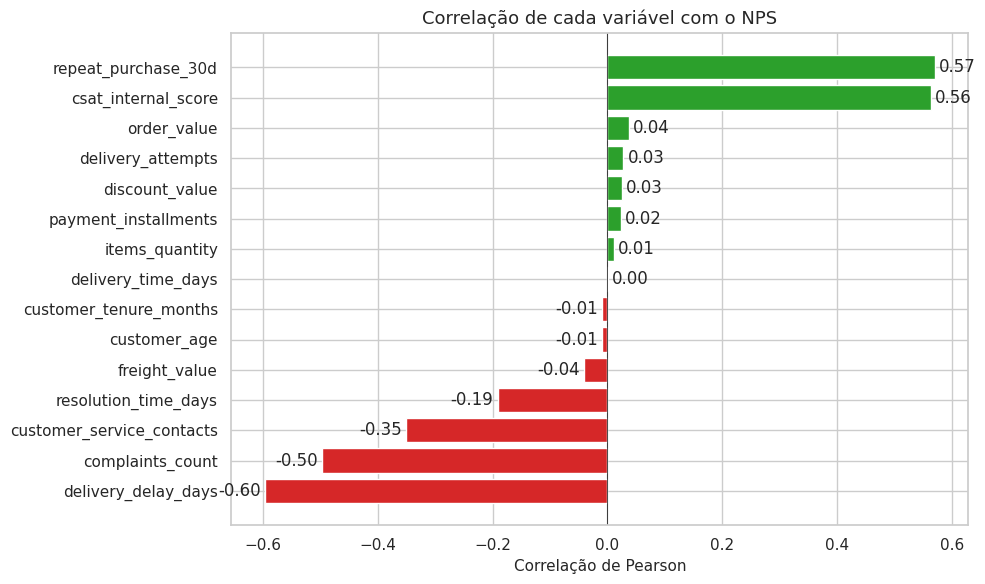

TOP DRIVERS POSITIVOS (mais NPS):
order_value            0.04
csat_internal_score    0.56
repeat_purchase_30d    0.57

TOP DRIVERS NEGATIVOS (menos NPS):
delivery_delay_days         -0.60
complaints_count            -0.50
customer_service_contacts   -0.35


In [13]:
# 5.2 Ranking de correlação com NPS
corr_nps = corr['nps_score'].drop('nps_score').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#d62728' if v < 0 else '#2ca02c' for v in corr_nps.values]
bars = ax.barh(corr_nps.index, corr_nps.values, color=cores)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Correlação de cada variável com o NPS')
ax.set_xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()

print('TOP DRIVERS POSITIVOS (mais NPS):')
print(corr_nps.tail(3).round(2).to_string())
print('\nTOP DRIVERS NEGATIVOS (menos NPS):')
print(corr_nps.head(3).round(2).to_string())

## 6. Salvar base preparada para a próxima etapa

In [14]:
# A base não precisou de tratamento, mas adicionamos a coluna de classificação
# Salvamos para uso no notebook de modelagem
df.to_csv('../data/desafio_nps_processado.csv', index=False)
print(f'Base preparada salva: {df.shape[0]} linhas, {df.shape[1]} colunas')
print('Colunas adicionadas: classificacao_nps')

Base preparada salva: 2500 linhas, 20 colunas
Colunas adicionadas: classificacao_nps


## 7. Resumo executivo dos achados

### O que descobrimos

| Achado | Impacto |
|---|---|
| **74% da base é detratora** | Situação crítica de satisfação |
| **NPS oficial ≈ -66** | Muito abaixo de qualquer benchmark de e-commerce |
| **Atraso é o pior driver** (corr ≈ -0.60) | A operação logística é a alavanca prioritária |
| **CSAT interno e recompra são bons preditores** | O modelo terá bons sinais |
| **Idade, tenure, valor do pedido pouco importam** | Demografia não explica — é problema operacional |
| **Regiões têm NPS parecidos** | Não é problema de uma filial — é sistêmico |

### Próximos passos (Notebook 2)

- Construir modelo preditivo de NPS (regressão e/ou classificação)
- Avaliar performance e importância das variáveis
- Gerar recomendações acionáveis para áreas de logística e atendimento